# Integrating with MaldiAMRKit (`MaldiSet`)

End-to-end workflow for users of the MaldiAMRKit ecosystem: start from a `MaldiSet`, delegate the batch-effect correction to MaldiBatchKit via `MaldiSetAdapter`, and keep MaldiAMRKit's downstream machinery (`.y`, `.filter(...)`, AMR evaluation) working on the corrected dataset.

Uses the **MALDI-Kleb-AI** dataset (Rocchi *et al.*, 2026; [Zenodo DOI 10.5281/zenodo.17405072](https://zenodo.org/records/17405072)); see notebook 01 for caching details. `load_maldi_kleb_ai` already builds a `MaldiSet` internally; we reach through `ds.maldi_set` to pass it to the adapter.


## 1. Load the MALDI-Kleb-AI MaldiSet


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from notebooks._demo import load_maldi_kleb_ai

demo = load_maldi_kleb_ai(antibiotic='Amikacin', verbose=True)
ds = demo.maldi_set
print(ds)
print('X shape:', ds.X.shape, '| y columns:', list(ds.y.columns))
ds.meta.head()

Processing spectra:   0%|          | 0/743 [00:00<?, ?spectrum/s]

MaldiSet(n_spectra=743, species='all', antibiotics=['Amikacin'])
X shape: (741, 6000) | y columns: ['Amikacin']


,Amikacin,Meropenem,Species,City
ID,,,,
FPG_2_9_spectrum,R,R,Klebsiella pneumoniae,Rome
FPG_2_15_spectrum,R,R,Klebsiella pneumoniae,Rome
FPG_2_47_spectrum,S,S,Klebsiella pneumoniae,Rome
FPG_2_55_spectrum,R,R,Klebsiella pneumoniae,Rome
FPG_2_57_spectrum,S,S,Klebsiella pneumoniae,Rome


## 2. Inspect the cross-centre batch effect


silhouette (before): 0.046


kBET acceptance (before): 0.239


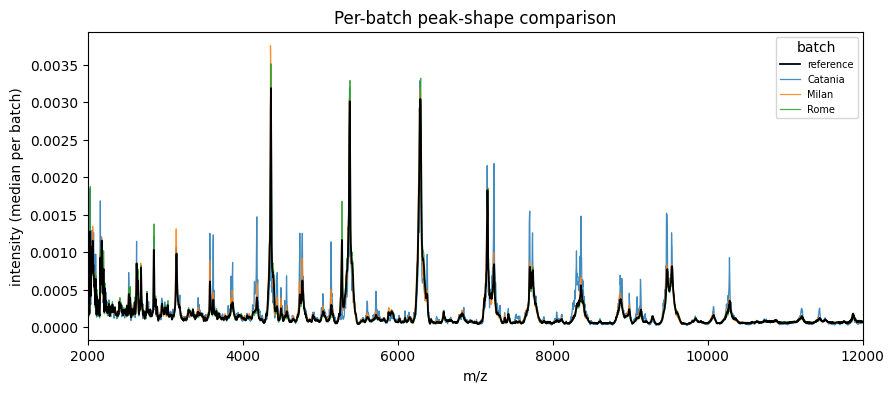

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
from maldibatchkit.diagnostics import silhouette_batch, kbet
from maldibatchkit.viz import plot_peak_shift

batch = ds.meta['City']   # Rome / Milan / Catania
print(f'silhouette (before): {silhouette_batch(ds.X, batch):.3f}')
print(f'kBET acceptance (before): {kbet(ds.X, batch)["acceptance_rate"]:.3f}')
fig, ax = plot_peak_shift(batch, ds.X, mz_values=demo.mz)
ax.set_xlim(2000, 12000)
plt.show()

## 3. Correct via `MaldiSetAdapter`


In [3]:
from maldibatchkit.integrations import MaldiSetAdapter
from maldibatchkit import SpeciesAwareComBat

adapter = MaldiSetAdapter(
    batch_column='City',
    species_column='Species',
    quality_column=None,   # SNR is stored on the DemoDataset, not on ds.meta
)
corrected_ds = adapter.correct(ds, SpeciesAwareComBat)

# Original dataset is untouched and the corrected MaldiSet keeps every property.
print('original X:', ds.X.shape, '| corrected X:', corrected_ds.X.shape)
print('AMR labels unchanged:', (ds.y.values == corrected_ds.y.values).all())
corrected_ds.meta.head()

original X: (741, 6000) | corrected X: (741, 6000)
AMR labels unchanged: True


,Amikacin,Meropenem,Species,City
1-8317003599,S,S,Klebsiella pneumoniae,Milan
10-8320002130,S,S,Klebsiella pneumoniae,Milan
100-8660007296,S,S,Klebsiella pneumoniae,Milan
1004,R,R,Klebsiella pneumoniae,Rome
101-8140000209,S,S,Klebsiella pneumoniae,Milan


## 4. Verify the correction


silhouette (after):  -0.001


kBET acceptance (after): 0.375


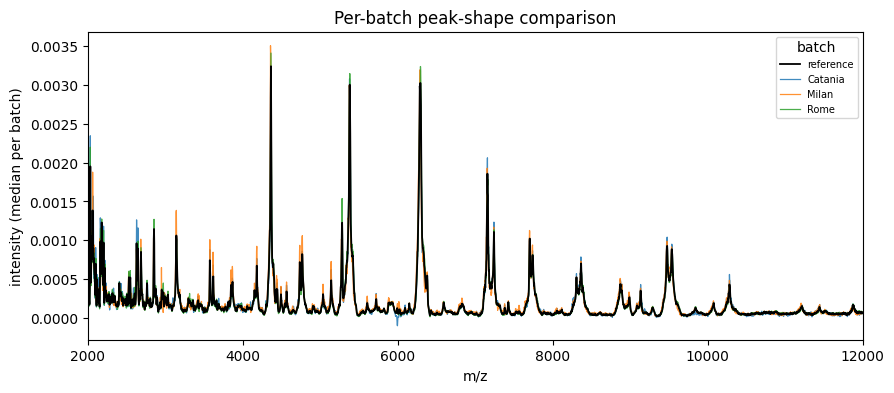

In [4]:
print(f'silhouette (after):  {silhouette_batch(corrected_ds.X, batch):.3f}')
print(f'kBET acceptance (after): {kbet(corrected_ds.X, batch)["acceptance_rate"]:.3f}')
fig, ax = plot_peak_shift(batch, corrected_ds.X, mz_values=demo.mz)
ax.set_xlim(2000, 12000)
plt.show()

## 5. Swap in a quality-weighted corrector


In [5]:
from maldibatchkit import QualityWeightedComBat

# Supply the SNR column computed by load_maldi_kleb_ai directly via transformer_kwargs.
qw_ds = adapter.correct(
    ds,
    QualityWeightedComBat,
    transformer_kwargs={'quality': demo.quality.loc[ds.X.index]},
)
print(f'silhouette (QW-ComBat): {silhouette_batch(qw_ds.X, batch):.3f}')
print(f'kBET acceptance (QW-ComBat): {kbet(qw_ds.X, batch)["acceptance_rate"]:.3f}')

silhouette (QW-ComBat): 0.011


kBET acceptance (QW-ComBat): 0.371


The adapter routes the `Species` column to `SpeciesAwareComBat`'s `species` argument automatically. Pass quality (SNR) through `transformer_kwargs` when it isn't already a column on `ds.meta`; if your `MaldiSet` has one, set `quality_column='<col_name>'` and the adapter will route it for you.


## 6. Continue with MaldiAMRKit downstream tools


In [6]:
# The corrected MaldiSet behaves exactly like the original.
kp_mask = corrected_ds.meta['Species'] == 'Klebsiella pneumoniae'
print(f'K. pneumoniae samples: {kp_mask.sum()} / {len(corrected_ds.meta)}')
# AMR label prevalence after correction (labels are untouched)
corrected_ds.y.apply(lambda s: s.value_counts()).T

K. pneumoniae samples: 684 / 741


Amikacin,S,R
Amikacin,372,369


## Summary

* `MaldiSetAdapter` takes a `MaldiSet` plus three column-name hints and returns a new `MaldiSet` whose `.X` yields the corrected matrix.
* Species-style metadata is routed to the transformer's categorical covariate slot automatically.
* The corrected dataset keeps working with every MaldiAMRKit feature: `.y`, `.meta`, `.filter(...)`, AMR evaluation, etc.
